In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")
plt.rcParams.update({
    'font.family': 'Arial',
    'font.size': 6,
    'axes.titlesize': 6,
    'axes.labelsize': 6,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 6,
    'figure.titlesize': 6,
    'figure.dpi': 200,
    'axes.linewidth': 0.7,
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

In [17]:
# Load the data
data = pd.read_csv('./data/ukb.stemloop_burden.WBnR.aggregate_mutation_association.binary.tsv', sep='\t')

# Process the variable names for better readability
data['variable_name'] = data['variable'].map(
    {
        'stem-loop': 'stem-loop (all exp)',
        'hde': 'HDE (all exp)',
        'stem-loop_highly_exp': 'stem-loop (highly exp)',
        'hde_highly_exp': 'HDE (highly exp)',
        'stem-loop_lowly_exp': 'stem-loop (lowly exp)',
        'hde_lowly_exp': 'HDE (lowly exp)',
    }
)

# Calculate odds ratios and intervals
data["OR"] = np.exp(data["beta"])
data["OR_ci_lower"] = np.exp(data["ci_lower"])
data["OR_ci_upper"] = np.exp(data["ci_upper"])

# Apply Bonferroni correction
data['p_bonferroni'] = data['p_value'].apply(
    lambda x: min(x * 6, 1.0)
)

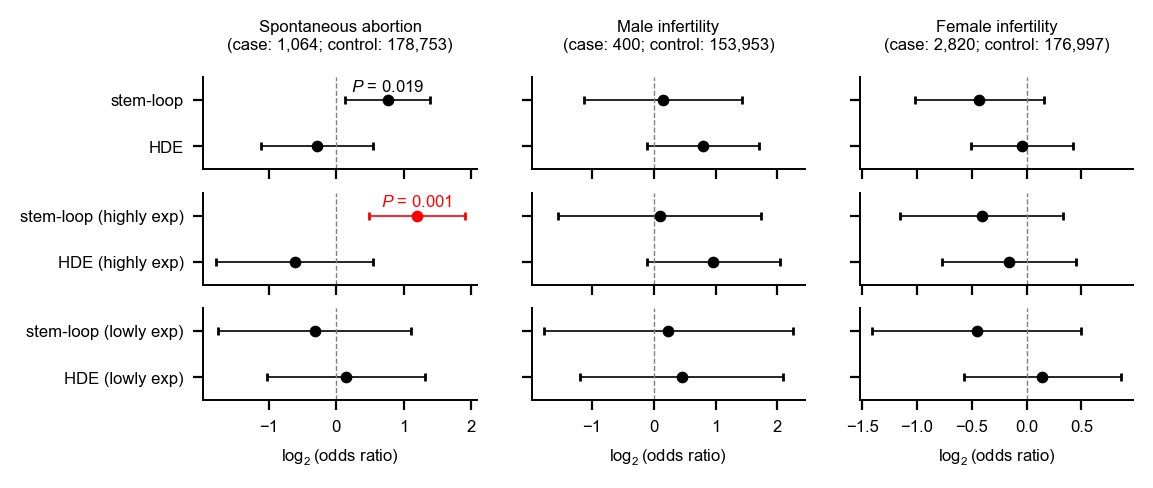

In [21]:
def get_star(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''


fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(6, 2.1),
    sharey='row',
    sharex='col',
)

for row_index, treat in enumerate(['all exp', 'highly exp', 'lowly exp']):

    for col_index, phenotype in enumerate(['Spontaneous abortion', 'Male infertility', 'Female infertility']):

        ax = axes[row_index, col_index]

        # Subset data
        sub_df = data[
            (data['phenotype'] == phenotype) &
            (data['variable_name'].str.contains(treat))
        ].copy()

        if sub_df.empty:
            # still format axes consistently
            ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.5)
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.set_yticks([])
            if row_index == 2:
                ax.set_xlabel(r'$\log_2(\mathrm{odds\ ratio})$')
            continue

        # y positions
        y_pos = np.arange(len(sub_df))

        # Convert OR and CI to log2 scale
        sub_df["OR"] = np.log2(sub_df["OR"])
        sub_df["OR_ci_lower"] = np.log2(sub_df["OR_ci_lower"])
        sub_df["OR_ci_upper"] = np.log2(sub_df["OR_ci_upper"])

        # Plot each point separately to control color per row
        for i, r in sub_df.reset_index(drop=True).iterrows():

            x = r["OR"]
            p = r["p_value"]
            y = y_pos[i]
            left_err = x - r["OR_ci_lower"]
            right_err = r["OR_ci_upper"] - x

            c = "red" if r["p_bonferroni"] < 0.05 else "black"
            ax.errorbar(
                x, y,
                xerr=[[left_err], [right_err]],
                fmt="o",
                color=c,
                ecolor=c,
                capsize=1.5,
                linewidth=0.6,
                markersize=3.2
            )
            # star = get_star(r["p_bonferroni"])
            star = ''
        
            if p < 0.05:
                ax.text(
                    x, y - 0.3, fr'$P$ = {p:.2g}{star}',
                    ha='center', va='center',
                    # fontsize=7,
                    color=c
                )

        # Reference line
        ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.5)

        # Axis formatting
        ax.set_ylim(-0.5, len(sub_df) - 0.5)
        ax.invert_yaxis()

        # X label only on bottom row
        if row_index == 2:
            ax.set_xlabel(r'$\log_2(\mathrm{odds\ ratio})$')

        # Remove top/right spines
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

        # Case / control counts (use first row as representative)
        row0 = sub_df.iloc[0]
        case_count = row0['case_have_variant_count'] + row0['case_no_variant_count']
        control_count = row0['control_have_variant_count'] + row0['control_no_variant_count']

        # Column titles (only top row)
        if row_index == 0:
            ax.set_title(
                f'{phenotype}\n(case: {case_count:,}; control: {control_count:,})',
                pad=10
            )

        # Set tick labels
        ax.set_yticks(y_pos)
        ax.set_yticklabels([i.replace(' (all exp)', '') for i in sub_df["variable_name"].to_list()])

# Increase spacing between panels (tune as needed)
fig.subplots_adjust(wspace=0.2, hspace=0.25)